# Lithographic pattern formation with the computed stigmatic DUV focus

**Use case:** turn the actual Fresnel-current focal field from the preceding
notebook into an image of an amplitude pattern. Inspect the output complex
vector field, the aerial image, the longitudinal contribution, and the effect
of illumination coherence and defocus.

This is a **local isoplanatic imaging experiment** using a computed point response
of the 193.368 nm conic. It is not propagation through the 48-surface patent
objective, nor a validation that the conic satisfies the sine condition over a
large field. The mask is specified at image scale; magnification is absorbed
into those coordinates. It is a thin amplitude object, with no electromagnetic
mask-topography or resist model.

A 4 mm waist Gaussian illuminates the conic; its smoothly illuminated aperture
reduces truncation of the coherent point response. This illumination differs
from the uniform plane wave in the preceding spot-size study.

The experiment is inspired by wavec's pattern-imaging studies, but the point
response here comes from vecdiff's **main per-k Fresnel surface calculation**.
No Richards–Wolf amplitudes enter this notebook.

In [1]:
from pathlib import Path
import sys

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()
)
sys.path.insert(0, str(root))
from IPython import get_ipython

get_ipython().run_line_magic("matplotlib", "inline")
import numpy as np
import matplotlib.pyplot as plt
from examples.notebook_tools import style, show, scalar_map, polarization_map, fwhm

style()

## 1. Calculate an electric impulse response, then its transfer function

For one input polarization and one focal plane,
$$\mathbf E_{im}(\mathbf r)=\int m(\boldsymbol\rho)
\mathbf h(\mathbf r-\boldsymbol\rho)\,d^2\rho.$$
This translation-invariant approximation is explicit. On the sampled periodic
cell it becomes a vector convolution. The FFT of the complex point response
provides three coherent transfer components, including the phase of $E_z$.
We normalize the on-axis, uniform-object response to unit electric norm; this
removes absolute system gain, so these plots cannot be used to claim throughput.

The calculation uses mm internally and µm for the mask coordinates. The
finite point-response window is a numerical approximation checked below.

Point response and transfer: 0.364 s
Local-kernel absolute E bound / PSF peak: 1.67%


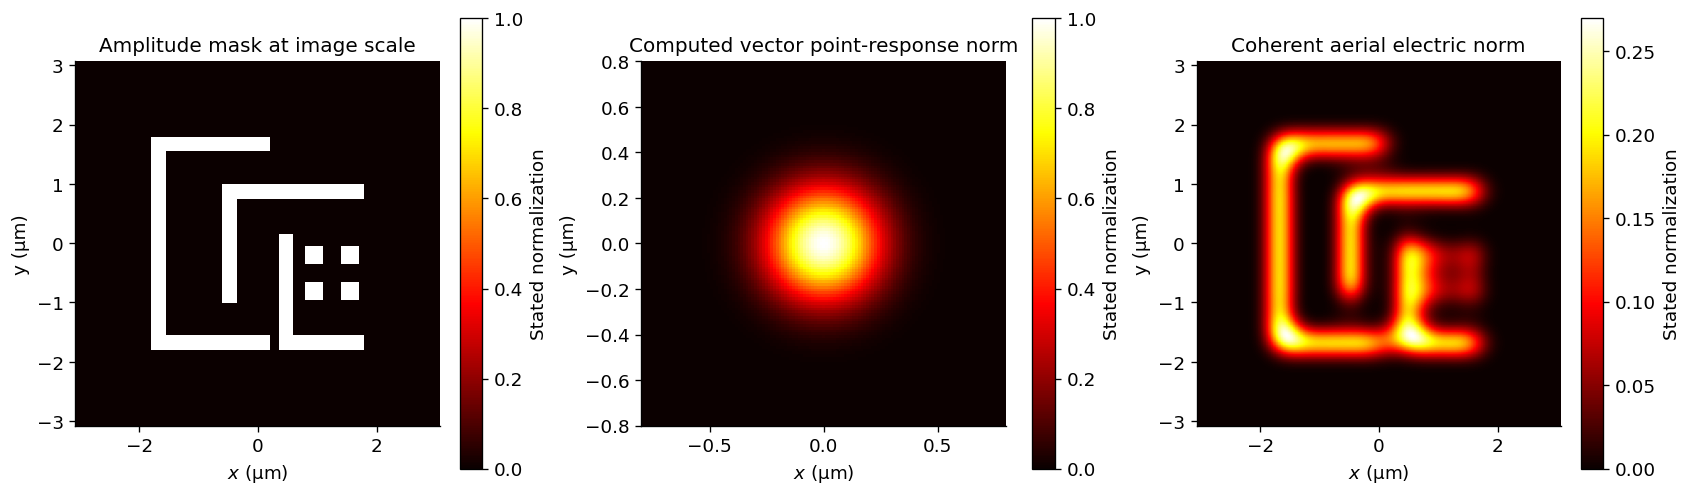

In [2]:
from time import perf_counter
from examples.macroscopic_focus import radiation, WAVELENGTH
from examples.image_formation import (
    circuit_pattern,
    coherent_image,
    aerial_image,
    disk_sources,
)

wavelength = WAVELENGTH
focus = np.array([0.0, 0.0, 20.0])
# A broad Gaussian input is synthesized as Maxwell plane waves, not painted onto a pupil.
from numpy.polynomial.hermite import hermgauss
from vecdiff import (
    ElectricSpectrum,
    EvenAsphere,
    Medium,
    DielectricInterface,
    sample_surface,
    interface_transform,
)

waist_mm = 4.0
nodes, weights = hermgauss(24)
KX, KY = np.meshgrid(2 * nodes / waist_mm, 2 * nodes / waist_mm)
kn = 2 * np.pi * 1.5 / wavelength
KZ = np.sqrt(kn**2 - KX * KX - KY * KY)
A = np.outer(weights, weights) / np.pi
amplitudes = np.stack((A, 0 * A, -KX * A / KZ), axis=-1)
beam = ElectricSpectrum(
    np.stack((KX, KY, KZ), axis=-1).reshape(-1, 3),
    amplitudes.reshape(-1, 3),
    wavelength,
    Medium(1.5),
)
surface = EvenAsphere(-0.1, -2.25)
samples = sample_surface(surface, (0, 12.0), (0, 2 * np.pi), 64, 192)
rad = interface_transform(
    beam, DielectricInterface(surface, Medium(1.5), Medium()), samples
).transmitted
count = 512
pixel = 0.012  # µm, image scale
x = (np.arange(count) - count // 2) * pixel
X, Y = np.meshgrid(x, x)


def transfer_from_radiation(rad, count, pixel, defocus=0.0):
    axis = (np.arange(count) - count // 2) * pixel * 1e-3
    X, Y = np.meshgrid(axis, axis)
    points = focus + np.stack((X, Y, np.full_like(X, defocus * 1e-3)), axis=-1)
    radius = float(np.sqrt(2 * max(abs(axis)) ** 2 + (defocus * 1e-3) ** 2) * 1.001)
    local = rad.local_spectrum(focus, radius)
    e, _ = local.evaluate(points, backend="nufft")
    transfer = (
        np.fft.fft2(np.fft.ifftshift(e, axes=(0, 1)), axes=(0, 1)) * (pixel * 1e-3) ** 2
    )
    return transfer, e, local


start = perf_counter()
raw, psf, local = transfer_from_radiation(rad, count, pixel)
gain = np.linalg.norm(raw[0, 0])
transfer = raw / gain
print(f"Point response and transfer: {perf_counter() - start:.3f} s")
print(
    f"Local-kernel absolute E bound / PSF peak: {local.electric_error_bound / np.max(np.linalg.norm(psf, axis=-1)):.2%}"
)
mask = circuit_pattern(x)
field = coherent_image(mask, transfer)
image = np.sum(abs(field) ** 2, axis=-1)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), layout="constrained")
for ax, values, title in zip(
    axes,
    [
        mask,
        np.sum(abs(psf) ** 2, axis=-1) / np.sum(abs(psf) ** 2, axis=-1).max(),
        image,
    ],
    [
        "Amplitude mask at image scale",
        "Computed vector point-response norm",
        "Coherent aerial electric norm",
    ],
):
    scalar_map(
        fig, ax, values, x, x, title, ylabel="y (µm)", label="Stated normalization"
    )
    ax.set_aspect("equal")
axes[1].set(xlim=(-0.8, 0.8), ylim=(-0.8, 0.8))
show(fig, "05_mask_psf_image")

## 2. Inspect the result field, not only an intensity curve

The complex vector image below is the output field for a **single coherent
illumination direction**. Real-part maps display a phasor snapshot, with a
diverging scale centered at zero. Component norm maps retain a common
normalization, and a local polarization map shows the nonuniform output state.
A longitudinal field can carry pattern information; it is not automatically
an unmodulated background.

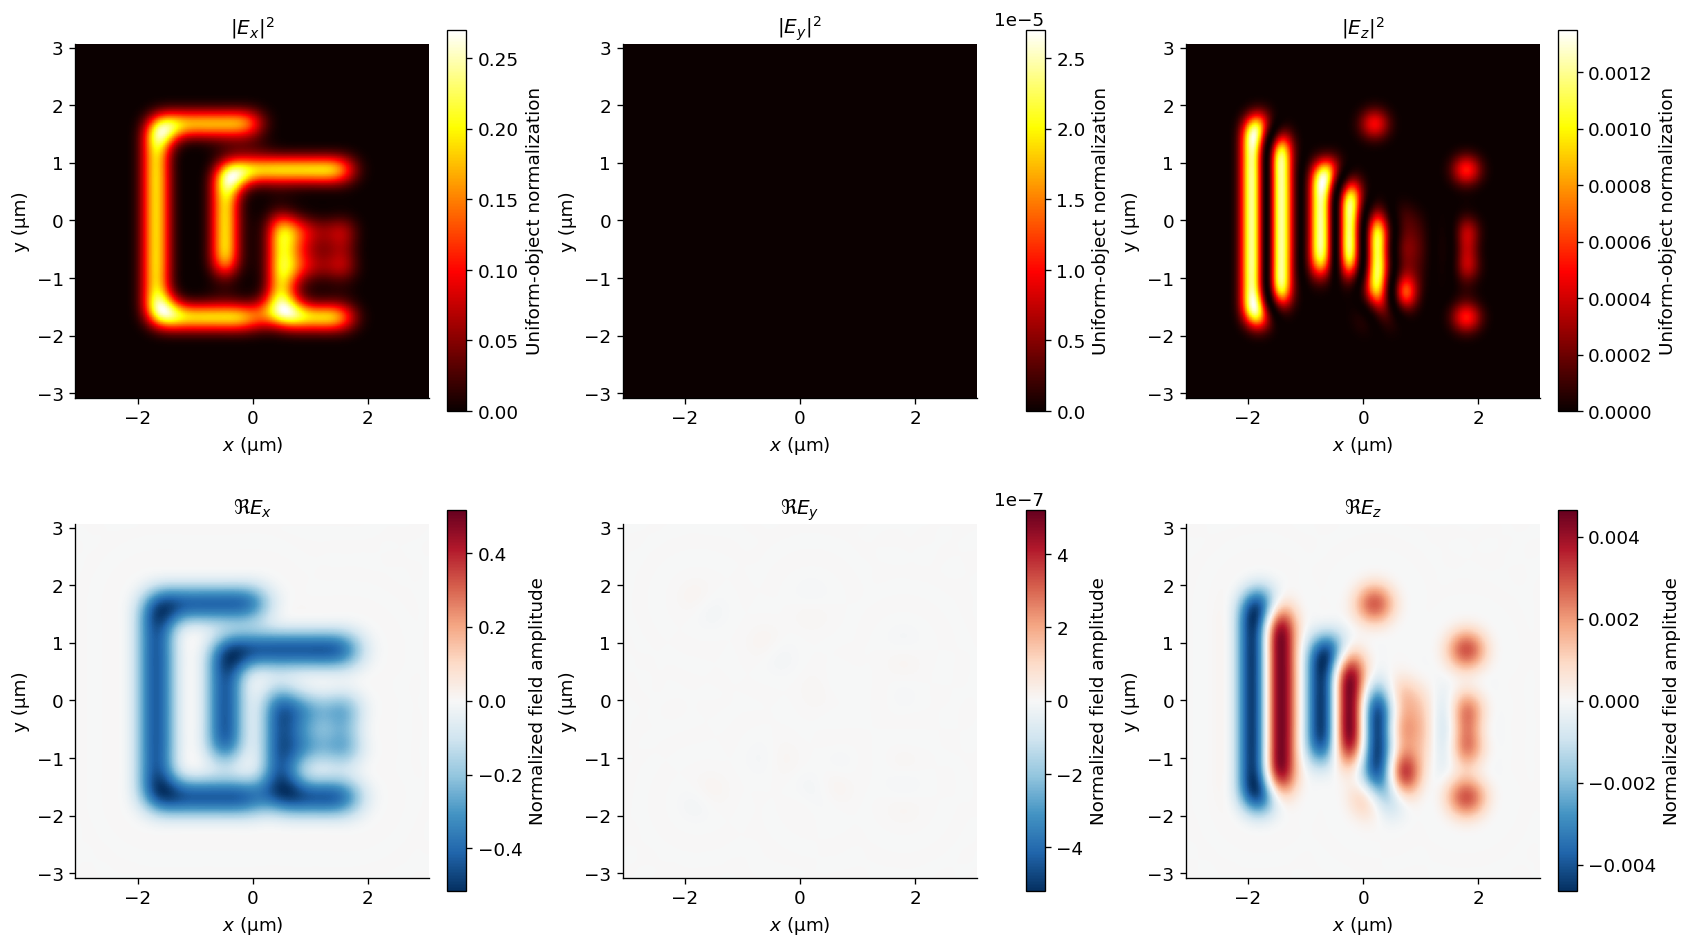

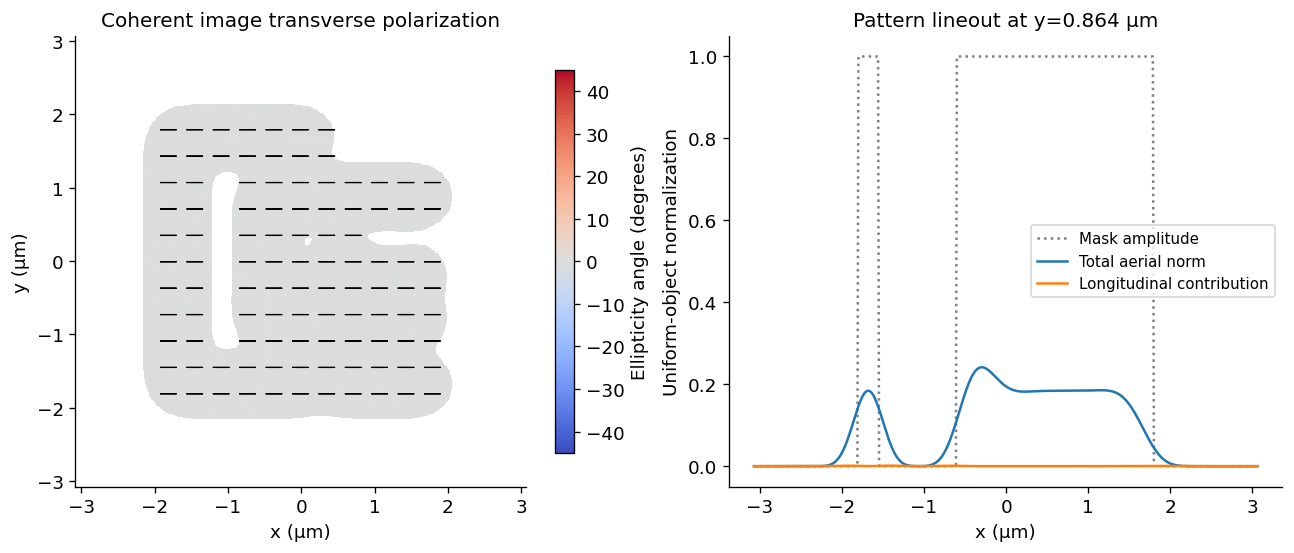

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), layout="constrained")
for j, name in enumerate(["x", "y", "z"]):
    scalar_map(
        fig,
        axes[0, j],
        abs(field[..., j]) ** 2,
        x,
        x,
        rf"$|E_{name}|^2$",
        ylabel="y (µm)",
        label="Uniform-object normalization",
        vmax=max(np.max(abs(field[..., j]) ** 2), 1e-4 * image.max()),
    )
    if np.max(abs(field[..., j]) ** 2) < 1e-14 * image.max():
        axes[0, j].text(
            0.5,
            0.5,
            "Numerically negligible",
            transform=axes[0, j].transAxes,
            ha="center",
            color="white",
            fontsize=9,
        )
    bound = max(np.max(abs(field[..., j].real)), 1e-6 * np.sqrt(image.max()))
    scalar_map(
        fig,
        axes[1, j],
        field[..., j].real,
        x,
        x,
        rf"$\Re E_{name}$",
        ylabel="y (µm)",
        label="Normalized field amplitude",
        cmap="RdBu_r",
        vmin=-bound,
        vmax=bound,
    )
for ax in axes.flat:
    ax.set_aspect("equal")
show(fig, "05_complex_image_field")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), layout="constrained")
polarization_map(
    fig, axes[0], field, x, x, title="Coherent image transverse polarization"
)
row = np.argmin(abs(x - 0.87))
axes[1].plot(x, mask[row], color="gray", ls=":", label="Mask amplitude")
axes[1].plot(x, image[row], label="Total aerial norm")
axes[1].plot(x, abs(field[row, :, 2]) ** 2, label="Longitudinal contribution")
axes[1].set(
    xlabel="x (µm)",
    ylabel="Uniform-object normalization",
    title=f"Pattern lineout at y={x[row]:.3f} µm",
)
axes[1].legend(fontsize=9)
show(fig, "05_polarization_lineout")

## 3. Change illumination coherence with an incoherent source sum

For mutually incoherent source points $s$, the aerial electric norm is
$$I(\mathbf r)=\sum_s w_s\|\mathbf E_s(\mathbf r)\|^2,\qquad\sum_s w_s=1.$$
We never add their phasors to create a fictitious “partially coherent field”.
The source disk is sampled on integer Fourier bins, so each tilted illumination
is exactly periodic on this cell. Its radius is $\sigma\,NA/\lambda_0$.
The point-source approximation and discrete source quadrature are explicit.

213 equally weighted source points: 2.212 s


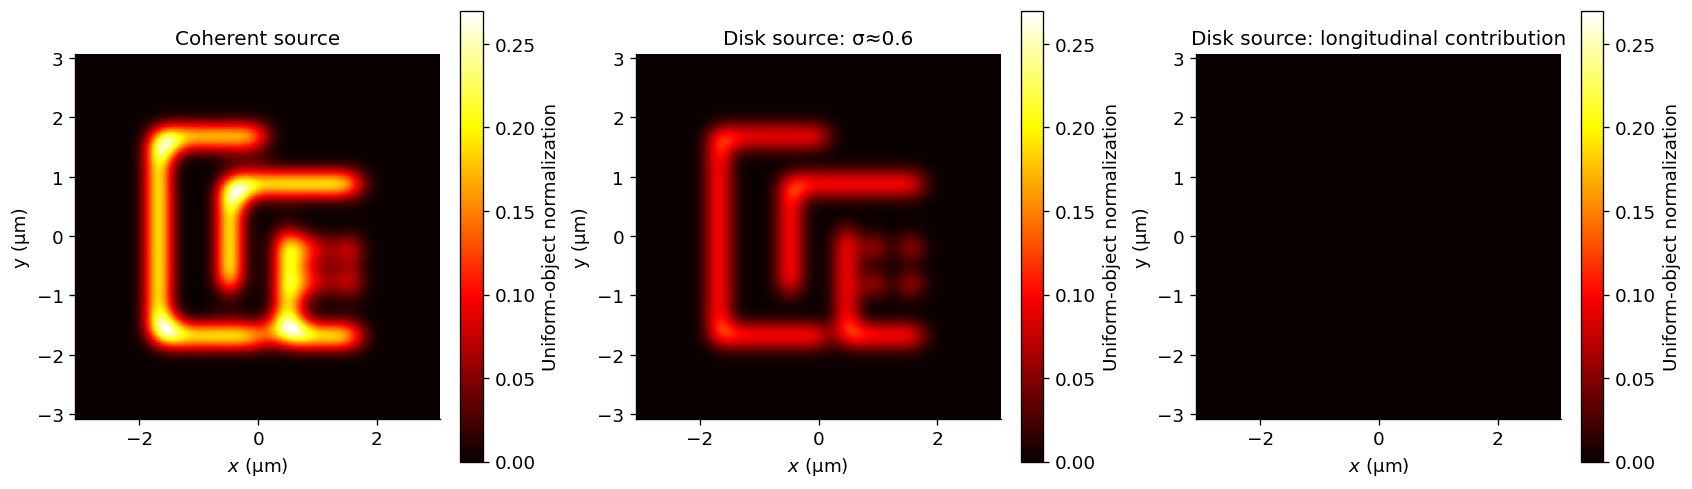

Longitudinal fraction of aerial electric norm: 0.830%


In [4]:
na = 12 / np.sqrt(12**2 + (20 - rad.sampling.surface.sag(12)) ** 2)
period = count * pixel
cutoff = na / (wavelength * 1e3)
sources = disk_sources(0.6 * cutoff * period)
start = perf_counter()
partial = aerial_image(mask, transfer, sources)
print(f"{len(sources)} equally weighted source points: {perf_counter() - start:.3f} s")
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), layout="constrained")
for ax, values, title in zip(
    axes,
    [image, partial.sum(axis=-1), partial[..., 2]],
    ["Coherent source", "Disk source: σ≈0.6", "Disk source: longitudinal contribution"],
):
    scalar_map(
        fig,
        ax,
        values,
        x,
        x,
        title,
        ylabel="y (µm)",
        label="Uniform-object normalization",
        vmax=max(image.max(), partial.sum(axis=-1).max()),
    )
    ax.set_aspect("equal")
show(fig, "05_partial_coherence")
print(
    f"Longitudinal fraction of aerial electric norm: {partial[..., 2].sum() / partial.sum():.3%}"
)

## 4. Measure through-focus image degradation

Defocus is applied by evaluating the same physical point response on a displaced
plane, not by blurring an intensity image. The central lineout shows the loss
of pattern modulation. The zero-defocus gain remains fixed across all planes.

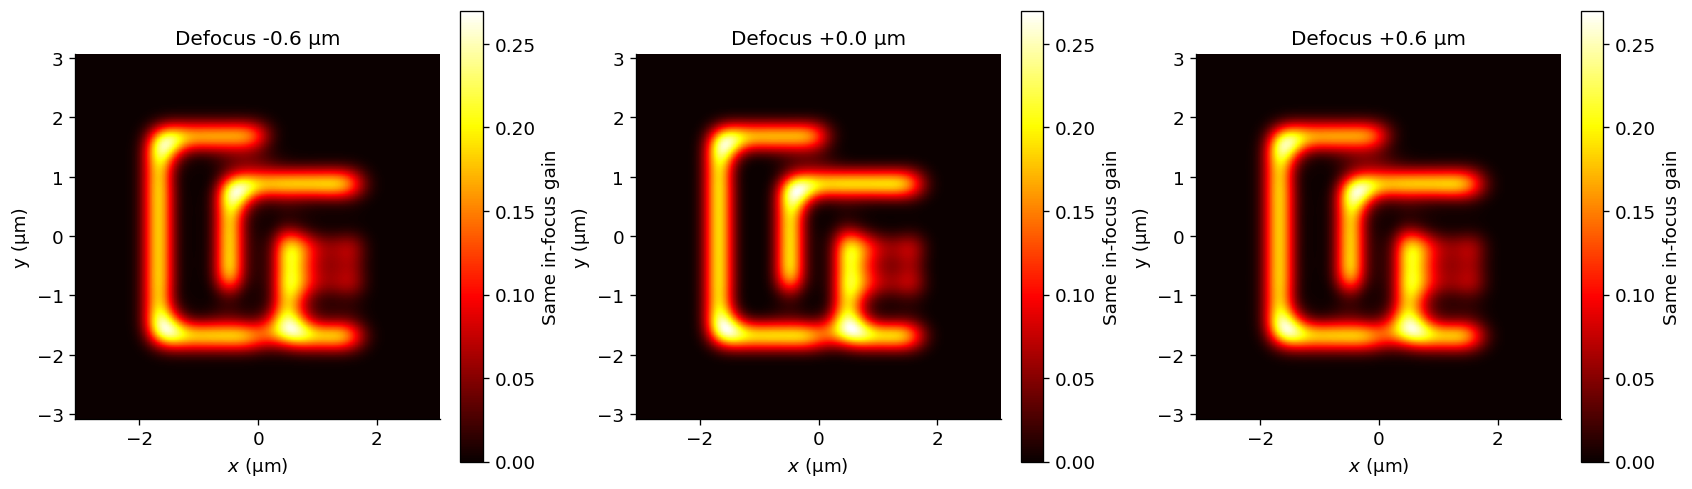

In [5]:
defocuses = [-0.6, 0, 0.6]  # µm
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), layout="constrained")
for ax, dz in zip(axes, defocuses):
    tf, _, _ = transfer_from_radiation(rad, count, pixel, defocus=dz)
    im = abs(coherent_image(mask, tf / gain)) ** 2
    scalar_map(
        fig,
        ax,
        im.sum(axis=-1),
        x,
        x,
        f"Defocus {dz:+.1f} µm",
        ylabel="y (µm)",
        label="Same in-focus gain",
        vmax=image.max(),
    )
    ax.set_aspect("equal")
show(fig, "05_defocused_pattern")

## 5. Test numerical sensitivity of the actual image

Double the point-response period while tiling the **same periodic object**;
compare the central cell, using the original gain. This tests the truncation of
the oscillatory coherent point response. Also refine source sampling and report
the change in the aerial image. Neither test validates the isoplanatic model
of a real off-axis optical system.

6.144 → 12.288 µm PSF window: relative complex-image change 0.002%
49 → 213 source points: relative aerial-image change 4.672%


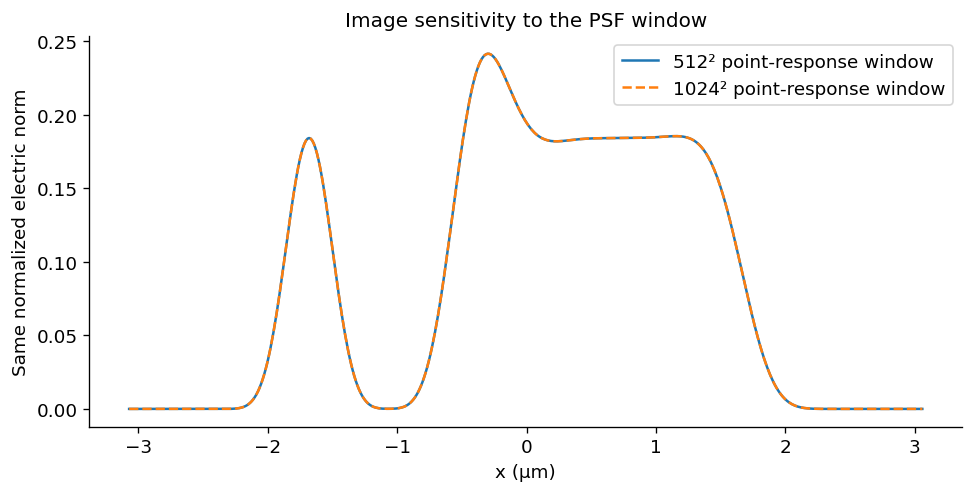

In [6]:
wide, _, _ = transfer_from_radiation(rad, 2 * count, pixel)
wide_image = coherent_image(np.tile(mask, (2, 2)), wide / gain)
# The mask repeats every count pixels; compare one complete cell.
window_error = np.linalg.norm(wide_image[:count, :count] - field) / np.linalg.norm(
    wide_image[:count, :count]
)
coarse_sources = disk_sources(0.6 * cutoff * period, step=2)
coarse = aerial_image(mask, transfer, coarse_sources).sum(axis=-1)
fine = partial.sum(axis=-1)
source_change = np.linalg.norm(coarse - fine) / np.linalg.norm(fine)
print(f"6.144 → 12.288 µm PSF window: relative complex-image change {window_error:.3%}")
print(
    f"{len(coarse_sources)} → {len(sources)} source points: relative aerial-image change {source_change:.3%}"
)
# Independent delta response and uniform-object controls of FFT conventions.
delta = np.zeros_like(mask)
delta[0, 0] = 1
recovered = coherent_image(delta, transfer)
assert np.allclose(
    recovered, np.fft.ifft2(transfer, axes=(0, 1)), rtol=1e-10, atol=1e-12
)
constant = coherent_image(np.ones_like(mask), transfer)
assert np.max(abs(np.sum(abs(constant) ** 2, axis=-1) - 1)) < 1e-10
assert window_error < 1e-3
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.plot(x, image[row], label="512² point-response window")
ax.plot(
    x,
    np.sum(abs(wide_image[:count, :count]) ** 2, axis=-1)[row],
    "--",
    label="1024² point-response window",
)
ax.set(
    xlabel="x (µm)",
    ylabel="Same normalized electric norm",
    title="Image sensitivity to the PSF window",
)
ax.legend()
show(fig, "05_image_convergence")

**Result to use:** the workflow produces a circuit-pattern image and its complex
vector field from the main method's computed point response. It also shows
partial coherence and defocus with explicit assumptions and numerical controls.
For a production lithography objective, field-dependent pupil data or propagation
through the actual prescription is required. Photoresist response, vector mask
scattering and process-window certification are outside this aerial-image model.